# Inspect `replay_buffer.zarr`

Loads a DP-style zarr replay buffer and shows:
- the zarr tree (group / dataset hierarchy)
- per-array shape, dtype, chunks, compressor, on-disk size
- episode count + per-episode length stats
- per-array value ranges + first-sample preview
- a grid of sample camera frames from one episode
- per-dimension plots of lowdim observations and actions over an episode

Default target: `data/ee2dice_zarr/replay_buffer.zarr` (relative to project root).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import zarr

%matplotlib inline

# --- config ---------------------------------------------------------------
ZARR_REL_PATH = 'data/ee2dice_zarr/replay_buffer.zarr'
EPISODE       = 0       # which episode to visualize
N_FRAMES      = 8       # how many frames to sample from the episode
# --------------------------------------------------------------------------

def _find_project_root() -> Path:
    for p in [Path.cwd()] + list(Path.cwd().parents):
        if (p / 'train.py').is_file() and (p / 'ImplicitRDP').is_dir():
            return p
    raise RuntimeError(f'cannot locate project root from {Path.cwd()}')

PROJECT_ROOT = _find_project_root()
ZARR_PATH    = PROJECT_ROOT / ZARR_REL_PATH
assert ZARR_PATH.exists(), f'zarr not found: {ZARR_PATH}'
print(f'project root : {PROJECT_ROOT}')
print(f'zarr path    : {ZARR_PATH.relative_to(PROJECT_ROOT)}')

project root : /home/ethan/workspaces/custom_training_pkg/ImplicitRDP
zarr path    : data/ee2dice_zarr/replay_buffer.zarr


## 1. Structure — tree, shapes, dtypes, chunks

In [2]:
def _disk_size(path: Path) -> int:
    return sum(f.stat().st_size for f in path.rglob('*') if f.is_file())

def _human(n: float) -> str:
    for unit in ['B', 'KB', 'MB', 'GB', 'TB']:
        if n < 1024:
            return f'{n:6.1f} {unit}'
        n /= 1024
    return f'{n:.1f} PB'

root = zarr.open(str(ZARR_PATH), mode='r')
print(f'on-disk size : {_human(_disk_size(ZARR_PATH))}')
print()
print('tree:')
print(root.tree())
print(f'{"key":<28s}  {"shape":<22s}  {"dtype":<10s}  {"chunks":<18s}  compressor')
print(f'{"-"*28}  {"-"*22}  {"-"*10}  {"-"*18}  {"-"*10}')
for grp_name in ['data', 'meta']:
    if grp_name not in root:
        continue
    for k, arr in root[grp_name].arrays():
        comp = arr.compressor.cname if arr.compressor is not None else 'none'
        print(f'{grp_name+"/"+k:<28s}  {str(arr.shape):<22s}  '
              f'{str(arr.dtype):<10s}  {str(arr.chunks):<18s}  {comp}')

on-disk size :  102.0 KB

tree:
/
 ├── data
 │   ├── action (939, 9) float32
 │   ├── eef_state (939, 9) float32
 │   └── rgb_hand (939, 256, 256, 3) uint8
 └── meta
     └── episode_ends (33,) int64
key                           shape                   dtype       chunks              compressor
----------------------------  ----------------------  ----------  ------------------  ----------
data/action                   (939, 9)                float32     (2048, 9)           lz4
data/eef_state                (939, 9)                float32     (2048, 9)           lz4
data/rgb_hand                 (939, 256, 256, 3)      uint8       (128, 256, 256, 3)  zstd
meta/episode_ends             (33,)                   int64       (33,)               lz4


## 2. Episode stats

episodes : 33
total T  : 939
ep length: min=16  median=28  max=46  mean=28.5


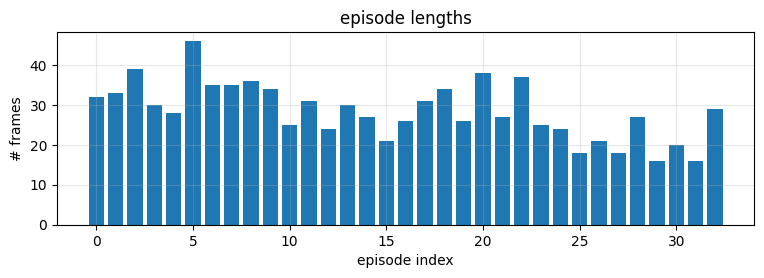

In [3]:
ep_ends   = np.asarray(root['meta']['episode_ends'][:])
ep_starts = np.concatenate([[0], ep_ends[:-1]])
ep_lens   = ep_ends - ep_starts
n_total   = int(ep_ends[-1]) if len(ep_ends) else 0

print(f'episodes : {len(ep_ends)}')
print(f'total T  : {n_total}')
if len(ep_lens):
    print(f'ep length: min={ep_lens.min()}  median={int(np.median(ep_lens))}  '
          f'max={ep_lens.max()}  mean={ep_lens.mean():.1f}')

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.bar(np.arange(len(ep_lens)), ep_lens)
ax.set_xlabel('episode index')
ax.set_ylabel('# frames')
ax.set_title('episode lengths')
ax.grid(alpha=0.3)
plt.show()

## 3. Per-array value ranges + first-sample preview

In [4]:
print(f'{"key":<28s}  {"first[0]":<40s}  {"min":>10s}  {"max":>10s}')
print(f'{"-"*28}  {"-"*40}  {"-"*10}  {"-"*10}')
for k, arr in root['data'].arrays():
    if arr.ndim == 0 or arr.shape[0] == 0:
        continue
    N = arr.shape[0]
    idx = np.linspace(0, N - 1, num=min(4096, N), dtype=np.int64)
    if arr.dtype == np.uint8 and arr.ndim >= 3:
        sample = np.asarray(arr[0])
        preview = f'img shape={sample.shape}'
        mn, mx = float(sample.min()), float(sample.max())
    else:
        sample_subset = np.asarray(arr[idx])
        head = np.asarray(arr[0]).ravel()[:8]
        preview = np.array2string(head, precision=3, suppress_small=True)
        mn, mx = float(sample_subset.min()), float(sample_subset.max())
    print(f'{k:<28s}  {preview:<40s}  {mn:>10.4g}  {mx:>10.4g}')

key                           first[0]                                         min         max
----------------------------  ----------------------------------------  ----------  ----------
action                        [-0.003 -0.332  0.157 -0.68   0.131 -0.722  0.273  0.958]     -0.8707      0.9981
eef_state                     [-0.003 -0.332  0.157 -0.68   0.131 -0.722  0.273  0.958]     -0.8707      0.9982
rgb_hand                      img shape=(256, 256, 3)                            0           0


## 4. Sample camera frames

Pulls `N_FRAMES` evenly-spaced frames from `episode=EPISODE` for every uint8 RGB array.

episode 0: frames 0…31  (sampling 8)
rgb keys      : ['rgb_hand']


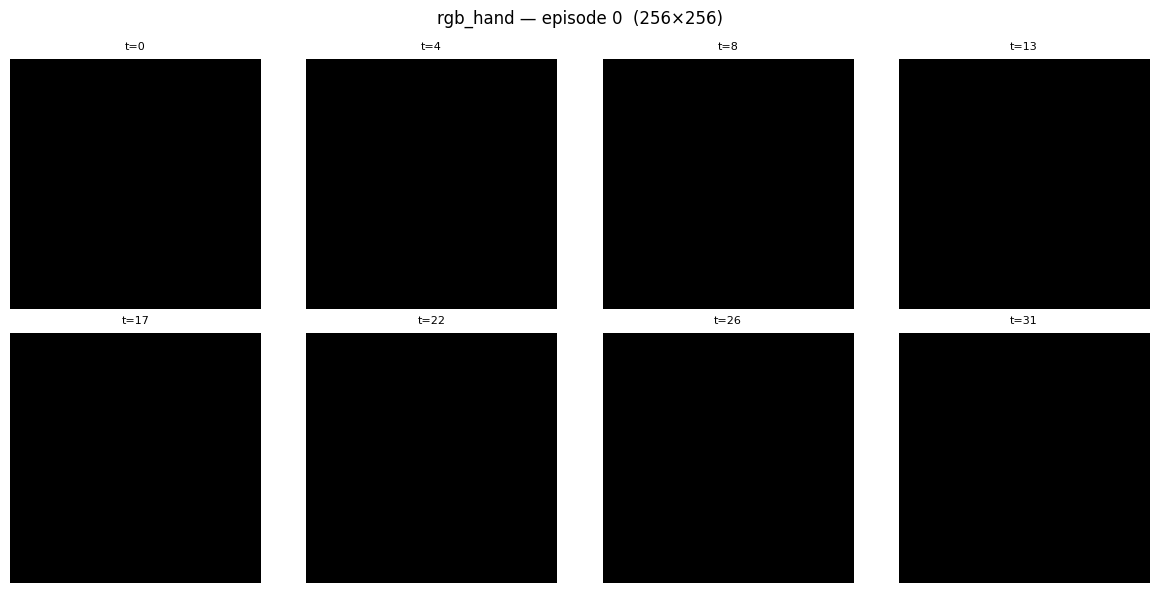

In [5]:
assert EPISODE < len(ep_ends), f'EPISODE {EPISODE} out of range (n={len(ep_ends)})'
start, end = int(ep_starts[EPISODE]), int(ep_ends[EPISODE])
frame_idxs = np.linspace(start, end - 1, num=N_FRAMES, dtype=np.int64)
rgb_keys   = [k for k, a in root['data'].arrays()
              if a.dtype == np.uint8 and a.ndim == 4]
print(f'episode {EPISODE}: frames {start}…{end-1}  (sampling {N_FRAMES})')
print(f'rgb keys      : {rgb_keys}')

for key in rgb_keys:
    arr  = root['data'][key]
    imgs = np.asarray(arr.get_orthogonal_selection((frame_idxs,)))
    cols = min(N_FRAMES, 4)
    rows = int(np.ceil(N_FRAMES / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3),
                             squeeze=False)
    for i, ax in enumerate(axes.ravel()):
        if i < N_FRAMES:
            ax.imshow(imgs[i])
            ax.set_title(f't={int(frame_idxs[i] - start)}', fontsize=8)
        ax.axis('off')
    fig.suptitle(f'{key} — episode {EPISODE}  ({arr.shape[1]}×{arr.shape[2]})')
    fig.tight_layout()
    plt.show()

## 5. Lowdim obs + action over the episode

One subplot per non-image array, each dimension as its own line.

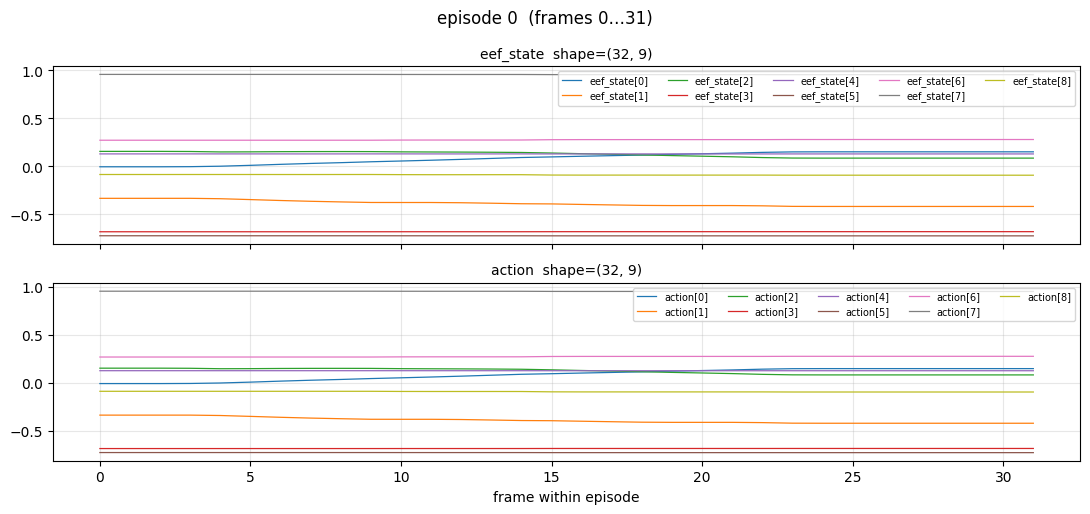

In [6]:
t = np.arange(end - start)

lowdim_keys = [k for k, a in root['data'].arrays()
               if a.dtype != np.uint8 and a.ndim == 2 and k != 'action']
action_key  = 'action' if 'action' in root['data'] else None

n_panels = len(lowdim_keys) + (1 if action_key else 0)
fig, axes = plt.subplots(n_panels, 1, figsize=(11, 2.6 * n_panels),
                         squeeze=False, sharex=True)
axes = axes.ravel()
panel = 0
for key in lowdim_keys:
    arr = np.asarray(root['data'][key][start:end])
    for d in range(arr.shape[1]):
        axes[panel].plot(t, arr[:, d], label=f'{key}[{d}]', linewidth=0.9)
    axes[panel].set_title(f'{key}  shape={arr.shape}', fontsize=10)
    axes[panel].legend(fontsize=7, ncol=min(arr.shape[1], 5), loc='upper right')
    axes[panel].grid(alpha=0.3)
    panel += 1
if action_key:
    arr = np.asarray(root['data'][action_key][start:end])
    for d in range(arr.shape[1]):
        axes[panel].plot(t, arr[:, d], label=f'action[{d}]', linewidth=0.9)
    axes[panel].set_title(f'action  shape={arr.shape}', fontsize=10)
    axes[panel].legend(fontsize=7, ncol=min(arr.shape[1], 5), loc='upper right')
    axes[panel].grid(alpha=0.3)
axes[-1].set_xlabel('frame within episode')
fig.suptitle(f'episode {EPISODE}  (frames {start}…{end-1})')
fig.tight_layout()
plt.show()

## 6. Single-frame drill-down

Useful for sanity-checking exactly what a single sample fed into the dataset looks like.

In [7]:
FRAME_IDX = start    # absolute frame index in the buffer
print(f'frame {FRAME_IDX} (episode {EPISODE}, t={FRAME_IDX - start})')
print('-' * 78)
for k, arr in root['data'].arrays():
    val = np.asarray(arr[FRAME_IDX])
    if arr.dtype == np.uint8 and val.ndim >= 2:
        print(f'{k:<28s}  {str(val.shape):<22s}  {arr.dtype}  '
              f'(min={val.min()}, max={val.max()})')
    else:
        print(f'{k:<28s}  {str(val.shape):<22s}  {arr.dtype}  '
              f'{np.array2string(val.ravel()[:8], precision=4, suppress_small=True)}')

frame 0 (episode 0, t=0)
------------------------------------------------------------------------------
action                        (9,)                    float32  [-0.0034 -0.3319  0.1569 -0.6799  0.1307 -0.7215  0.2731  0.9583]
eef_state                     (9,)                    float32  [-0.0034 -0.3319  0.1569 -0.6799  0.1307 -0.7216  0.2731  0.9583]
rgb_hand                      (256, 256, 3)           uint8  (min=0, max=0)
